# 121. Best Time to Buy and Sell Stock
**Difficulty:** 🟢 Easy · **Topic:** Array · **LeetCode:** https://leetcode.com/problems/best-time-to-buy-and-sell-stock/

## 💡 Concepts

**Core concept(s):** A single left-to-right pass that keeps a *running minimum* (greedy).

**Why it applies here:** Profit for selling on day `j` is `price[j] - (cheapest price on any day before j)`. So if we always remember the **minimum price seen so far**, then at each day we can compute the best profit achievable by selling that day in O(1). The overall answer is the max of those.

**Key intuition / mental model:** Walk the prices once. Maintain two numbers: the lowest buy price up to now, and the best profit found so far. Each new price either lowers the buy price or raises the profit — never both.

---

### 📚 What is a "running (prefix) aggregate"?
A **running aggregate** is a value you update as you sweep the array so that at index `i` it summarizes everything in `[0..i]` — e.g. running **min**, **max**, or **sum**. It removes the need for an inner loop that re-scans the prefix.
- **Complexity:** updated in **O(1)** per element → **O(n)** total, **O(1)** extra space.
- **In Python:** just a plain variable you reassign with `min(...)`, `max(...)`, or `+=`.

### 📚 What is a "Greedy" approach?
**Greedy** means making the locally-best choice at each step and never reconsidering it, trusting that these local optima compose into a global optimum. It only works when the problem has that structure — here it does, because the best buy day for any sell day is simply the cheapest earlier day.
- **Complexity:** typically a single pass, **O(n)**.

## 📝 Problem

Given `prices` where `prices[i]` is the stock price on day `i`, choose **one** day to buy and a **later** day to sell to maximize profit. Return the max profit, or `0` if no profit is possible.

**Example**
```
Input:  prices = [7, 1, 5, 3, 6, 4]
Output: 5        # buy at 1 (day 1), sell at 6 (day 4)
```
**Constraints:** `1 <= len(prices) <= 10^5`.

> Only **two** meaningfully distinct approaches are shown — an O(n²) brute force and the O(n) optimal. (A divide-and-conquer variant exists but adds complexity without new insight.)

### Approach 1 — Brute Force (worst)

**Idea:** Try every buy day `i` and every later sell day `j`, track the largest `prices[j] - prices[i]`.

**Time complexity:** `O(n^2)` — all pairs `i < j`.

**Space complexity:** `O(1)`.

In [1]:
from typing import List

def max_profit_brute(prices: List[int]) -> int:
    best = 0
    n = len(prices)
    for i in range(n):                     # buy day
        for j in range(i + 1, n):          # sell day must be LATER than the buy day
            best = max(best, prices[j] - prices[i])  # track the biggest profit seen
    return best

### Approach 2 — One-Pass Running Minimum (optimal)

**Idea:** Sweep once. Keep `min_price` = cheapest day so far. At each price, the best profit if we sell today is `price - min_price`; keep the max of those.

**Time complexity:** `O(n)` — single pass.

**Space complexity:** `O(1)`.

In [2]:
from typing import List

def max_profit_optimal(prices: List[int]) -> int:
    min_price = float("inf")               # cheapest buy price seen so far
    best = 0                               # best profit found so far
    for p in prices:                       # walk the days left to right
        min_price = min(min_price, p)      # is today a new cheapest day to buy?
        best = max(best, p - min_price)    # best profit if we sold today
    return best

In [3]:
# Correctness check
tests = [
    ([7, 1, 5, 3, 6, 4], 5),
    ([7, 6, 4, 3, 1], 0),                  # only falling -> no profit
    ([1, 2], 1),
    ([3], 0),
]
for prices, expected in tests:
    b, o = max_profit_brute(prices), max_profit_optimal(prices)
    print(f"{prices} -> brute={b}, optimal={o} | expected={expected}")
    assert b == o == expected, "mismatch!"
print("\nAll tests passed")

[7, 1, 5, 3, 6, 4] -> brute=5, optimal=5 | expected=5
[7, 6, 4, 3, 1] -> brute=0, optimal=0 | expected=0
[1, 2] -> brute=1, optimal=1 | expected=1
[3] -> brute=0, optimal=0 | expected=0

All tests passed


## ⏱️ Empirically Checking the Complexities

Big-O can't be read off a function directly, but it can be **measured**. We time each approach on inputs of growing `n` and read the **doubling ratio** — how much runtime grows when `n` doubles.

| Theoretical | Ratio when `n` → `2n` |
|-------------|-----------------------|
| `O(log n)`    | ≈ **1×** |
| `O(n)`        | ≈ **2×** |
| `O(n log n)`  | ≈ **2×** (slightly more) |
| `O(n²)`       | ≈ **4×** |
| `O(n³)`       | ≈ **8×** |

Inputs are built to force the **worst case** (no early exit) so the measurement reflects the true bound. Sub-millisecond rows are noisy — look at the trend, not one number.


brute   O(n^2)
        n |  time (ms) | ratio vs prev
  ------- | ---------- | -------------
     1000 |     113.50 |           n/a
     2000 |     417.29 |         3.68x
     4000 |    1671.55 |         4.01x
     8000 |    7002.93 |         4.19x

optimal O(n)  
        n |  time (ms) | ratio vs prev
  ------- | ---------- | -------------
     1000 |       0.33 |           n/a
     2000 |       0.64 |         1.94x
     4000 |       1.36 |         2.13x
     8000 |       2.58 |         1.90x

Ratios per doubling: ~1x=>constant/log, ~2x=>linear or n log n, ~4x=>quadratic, ~8x=>cubic.


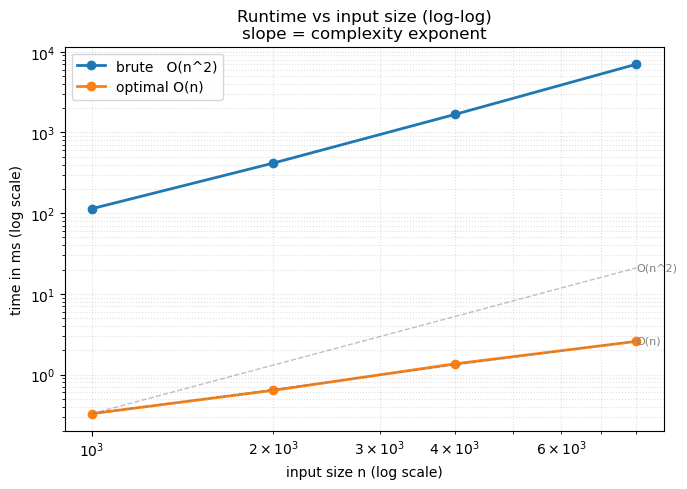

{'brute   O(n^2)': [113.49679998238571,
  417.2864000138361,
  1671.5510000067297,
  7002.928700007033],
 'optimal O(n)  ': [0.3279999946244061,
  0.6376999954227358,
  1.3578999787569046,
  2.577100007329136]}

In [4]:
import os, sys
_root = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_root, "bench_utils.py")):
        break
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
from bench_utils import benchmark   # shared: prints ratio table + optional log-log plot

def make_worst_case(n):
    prices = list(range(1, n + 1))         # strictly increasing -> brute never short-circuits
    return (prices,)

solutions = {
    "brute   O(n^2)": max_profit_brute,
    "optimal O(n)  ": max_profit_optimal,
}
sizes = [1000, 2000, 4000, 8000]

benchmark(solutions, make_worst_case, sizes, plot=True)


## 🧩 Patterns Learned

- **Running minimum / single-pass greedy:** When each element's answer depends only on an aggregate of everything before it, keep that aggregate in a variable and update it in O(1) — collapses O(n²) into O(n).
- **Signal to reach for it:** "best/max/min over all pairs where one comes before the other", "max difference `a[j]-a[i]` with `j>i`".
- **Related problems:** Maximum Subarray (Kadane), Best Time to Buy/Sell Stock II, Trapping Rain Water (prefix max), Sliding Window Maximum.
- **Common pitfalls:** (1) allowing sell before buy; (2) initializing profit to `-inf` instead of `0` when "no transaction" is allowed; (3) recomputing the min inside an inner loop instead of carrying it.